
# Fairness Audit — *Socioeconomic Bias* (Income, Education, Employment)

This notebook evaluates **model performance disparities** across **socioeconomic groups** using the columns already present in your dataset:
- **Income** → grouped into tertiles (Low / Medium / High)
- **Education** → mapped to human-readable levels
- **EmploymentType** → mapped to human-readable classes

We compute per-group **Accuracy, Precision, Recall, Selection Rate** and quantify disparities (max-min).  
We also include a **threshold sweep** to visualize selection-rate vs. recall tradeoffs by group.


In [44]:
import os
print(os.getcwd())
print(os.listdir())


/Users/taneshafuller/Documents/GitHub/AI4ALL_Credit_Risk
['fairness_audit (1).ipynb', '.DS_Store', 'data_cleaning.ipynb', 'anaconda_projects', 'rf.ipynb', 'README.md', 'logistic_regression.ipynb', 'xgb.ipynb', '.ipynb_checkpoints', 'random_forest.ipynb', 'fairness_outputs', 'loan_default_preprocessed.csv', '.git', 'loan_default.csv']


## 1) Setup & Data Load

In [45]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

%matplotlib inline

CLEAN = "loan_default_preprocessed.csv"
RAW   = "loan_default.csv"

if os.path.exists(CLEAN):
    df = pd.read_csv(CLEAN)
    source_used = CLEAN
elif os.path.exists(RAW):
    df = pd.read_csv(RAW)
    source_used = RAW
else:
    raise FileNotFoundError("No input CSV found. Expected loan_default_preprocessed.csv or loan_default.csv.")

df.columns = [c.strip() for c in df.columns]
print(f"Loaded: {source_used} | shape={df.shape}")
df.head()


Loaded: loan_default_preprocessed.csv | shape=(255347, 17)


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,1,4,2,1,1,3,1,0
1,69,50432,124440,458,15,1,4.81,60,0.68,2,4,1,0,0,3,1,0
2,46,84208,129188,451,26,3,21.17,24,0.31,2,0,2,1,1,4,0,1
3,32,31713,44799,743,0,3,7.07,24,0.23,0,4,1,0,0,0,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,1,0,2,0,1,4,0,0


## 2) Train a Compact Baseline Model

In [46]:

max_rows = 20000
if len(df) > max_rows:
    df = df.sample(n=max_rows, random_state=42).reset_index(drop=True)

target_col = "Default"
assert target_col in df.columns, "Expected target column 'Default' not found."

X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()
if y.dtype == 'O' and y.nunique() == 2:
    y = y.astype('category').cat.codes

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y if y.nunique()==2 else None
)

cat_cols = [c for c in X_train.columns if X_train[c].dtype == 'O']
num_cols = [c for c in X_train.columns if c not in cat_cols]

numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocess = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

rf = RandomForestClassifier(n_estimators=120, random_state=42, n_jobs=-1)
clf = Pipeline(steps=[("preprocess", preprocess), ("rf", rf)])
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
if hasattr(clf, "predict_proba"):
    y_proba = clf.predict_proba(X_test)[:,1]
else:
    y_proba = (y_pred - y_pred.min()) / (y_pred.max() - y_pred.min() + 1e-9)

overall = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
}
try:
    overall["roc_auc"] = roc_auc_score(y_test, y_proba)
except Exception:
    pass

pd.DataFrame([overall])


,accuracy,precision,recall,roc_auc
0,0.8884,0.708333,0.02993,0.726173


## 3) Define Socioeconomic Groups

In [47]:

df_full = df.copy()

# Income → terciles
if "Income" in df_full.columns:
    try:
        df_full["income_bracket"] = pd.qcut(df_full["Income"], q=3, labels=["Low","Medium","High"], duplicates="drop")
    except Exception:
        df_full["income_bracket"] = pd.cut(df_full["Income"], bins=3, labels=["Low","Medium","High"])

# Education mapping
if "Education" in df_full.columns:
    if not np.issubdtype(df_full["Education"].dtype, np.number):
        df_full["education_level"] = df_full["Education"].astype(str)
    else:
        edu_map = {0:"None",1:"High School",2:"Bachelors",3:"Masters",4:"Doctorate"}
        df_full["education_level"] = df_full["Education"].map(edu_map).fillna(df_full["Education"].astype(str))

# Employment mapping
if "EmploymentType" in df_full.columns:
    if not np.issubdtype(df_full["EmploymentType"].dtype, np.number):
        df_full["employment_class"] = df_full["EmploymentType"].astype(str)
    else:
        emp_map = {0:"Unemployed",1:"Part-time",2:"Full-time",3:"Self-employed",4:"Contractor"}
        df_full["employment_class"] = df_full["EmploymentType"].map(emp_map).fillna(df_full["EmploymentType"].astype(str))

# Align groups to test rows
df_full = df_full.reset_index().rename(columns={"index":"_row_id"})
X_ids = X.reset_index().rename(columns={"index":"_row_id"})
test_ids = X_test.reset_index().rename(columns={"index":"_row_id"})["_row_id"]
df_groups = df_full.set_index("_row_id").loc[test_ids]

df_groups[["income_bracket","education_level","employment_class"]].head()


,income_bracket,education_level,employment_class
_row_id,,,
468,Low,Bachelors,Full-time
12624,Medium,Bachelors,Contractor
12898,High,Bachelors,Part-time
12235,High,Bachelors,Full-time
13533,Low,High School,Full-time


## 4) Group Metrics and Disparities

In [48]:

def group_metrics(y_true, y_pred, labels: pd.Series) -> pd.DataFrame:
    out = []
    groups = pd.Series(labels).astype(str)
    for g in sorted(groups.dropna().unique()):
        mask = (groups == g)
        yt = y_true[mask.values]
        yp = y_pred[mask.values]
        out.append({
            "group": g,
            "count": int(mask.sum()),
            "accuracy": accuracy_score(yt, yp),
            "precision": precision_score(yt, yp, zero_division=0),
            "recall": recall_score(yt, yp, zero_division=0),
            "selection_rate": float(np.mean(yp))
        })
    return pd.DataFrame(out).sort_values("group").reset_index(drop=True)

results = {}
if "income_bracket" in df_groups:
    results["Income"] = group_metrics(y_test.reset_index(drop=True), pd.Series(y_pred).reset_index(drop=True), df_groups["income_bracket"].reset_index(drop=True))
if "education_level" in df_groups:
    results["Education"] = group_metrics(y_test.reset_index(drop=True), pd.Series(y_pred).reset_index(drop=True), df_groups["education_level"].reset_index(drop=True))
if "employment_class" in df_groups:
    results["Employment"] = group_metrics(y_test.reset_index(drop=True), pd.Series(y_pred).reset_index(drop=True), df_groups["employment_class"].reset_index(drop=True))

for name, table in results.items():
    print(f"\n=== {name} ===")
    display(table)



=== Income ===


,group,count,accuracy,precision,recall,selection_rate
0,High,1671,0.906643,0.000000,0.000000,0.000000
1,Low,1650,0.866061,0.695652,0.069565,0.013939
2,Medium,1679,0.892198,1.000000,0.005495,0.000596



=== Education ===


,group,count,accuracy,precision,recall,selection_rate
0,Bachelors,1234,0.896272,0.714286,0.038168,0.005673
1,High School,1255,0.874900,0.666667,0.025157,0.004781
2,Masters,1264,0.909019,0.800000,0.033898,0.003956
3,None,1247,0.873296,0.666667,0.025000,0.004812



=== Employment ===


,group,count,accuracy,precision,recall,selection_rate
0,Contractor,1260,0.897619,0.400000,0.015625,0.003968
1,Full-time,1265,0.875099,0.666667,0.025000,0.004743
2,Part-time,1258,0.908585,0.750000,0.025641,0.003180
3,Unemployed,1217,0.871816,0.888889,0.049080,0.007395


### Disparity Summary (max - min across groups)

In [49]:

def disparity(table: pd.DataFrame) -> pd.Series:
    return pd.Series({
        "acc_gap": table["accuracy"].max() - table["accuracy"].min(),
        "prec_gap": table["precision"].max() - table["precision"].min(),
        "recall_gap": table["recall"].max() - table["recall"].min(),
        "select_gap": table["selection_rate"].max() - table["selection_rate"].min()
    })

disp_rows = []
for name, table in results.items():
    s = disparity(table)
    s.name = name
    disp_rows.append(s)

disparities = pd.DataFrame(disp_rows)
display(disparities)

print("Interpretation tip: Gaps ≥ ~0.10–0.15 in recall/precision are often practically meaningful.")


,acc_gap,prec_gap,recall_gap,select_gap
Income,0.040582,1.000000,0.069565,0.013939
Education,0.035723,0.133333,0.013168,0.001717
Employment,0.036769,0.488889,0.033455,0.004216


Interpretation tip: Gaps ≥ ~0.10–0.15 in recall/precision are often practically meaningful.


## 5) Visualize Group Performance

<Figure size 800x400 with 0 Axes>

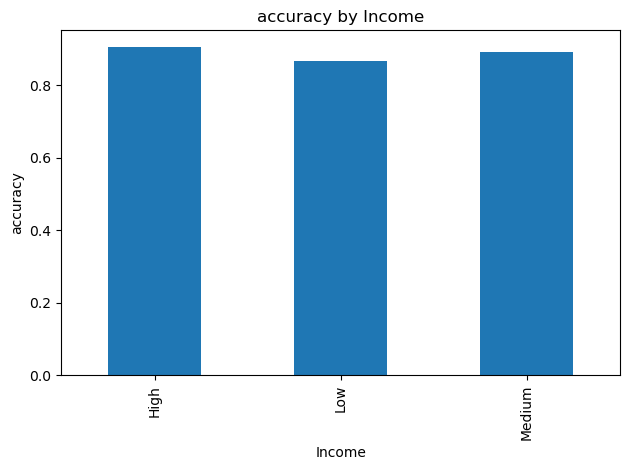

<Figure size 800x400 with 0 Axes>

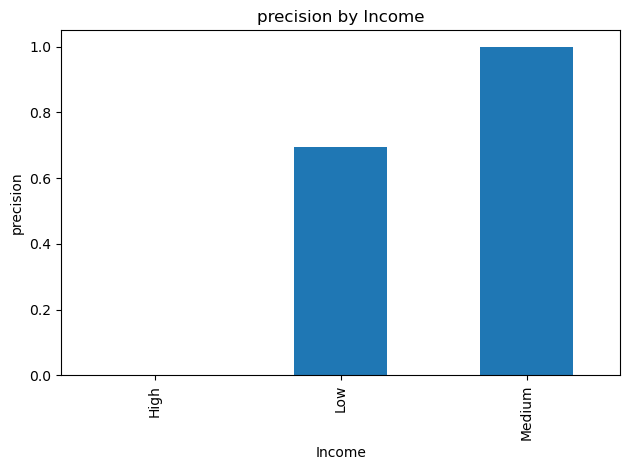

<Figure size 800x400 with 0 Axes>

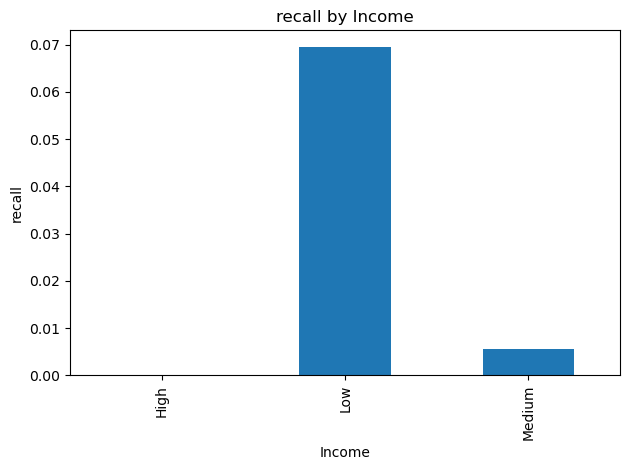

<Figure size 800x400 with 0 Axes>

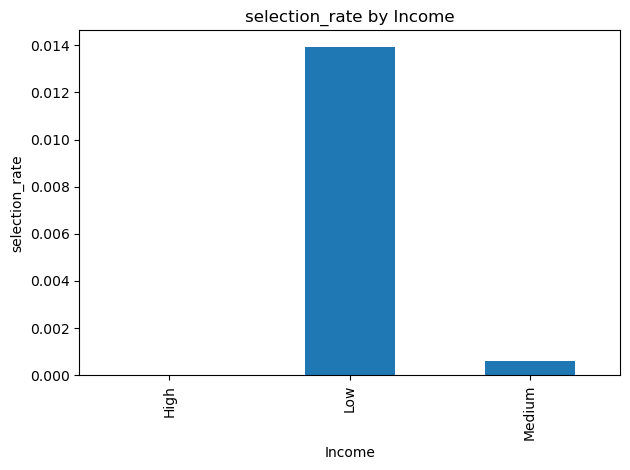

<Figure size 800x400 with 0 Axes>

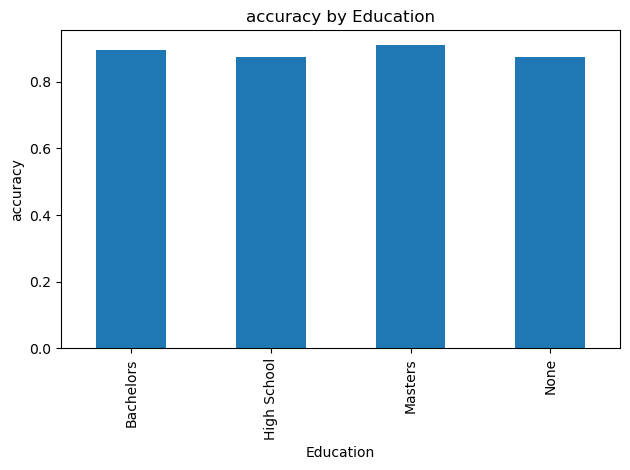

<Figure size 800x400 with 0 Axes>

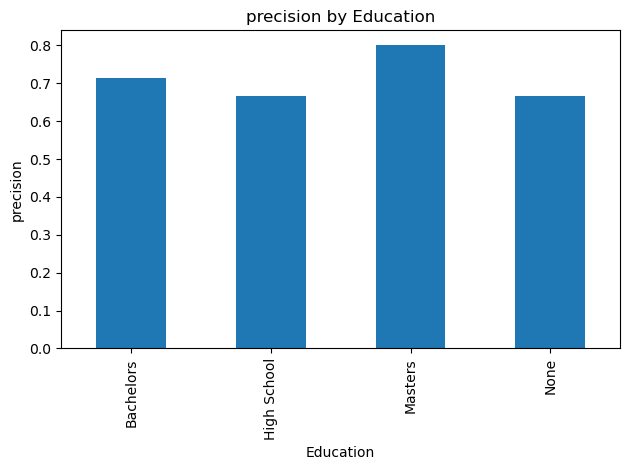

<Figure size 800x400 with 0 Axes>

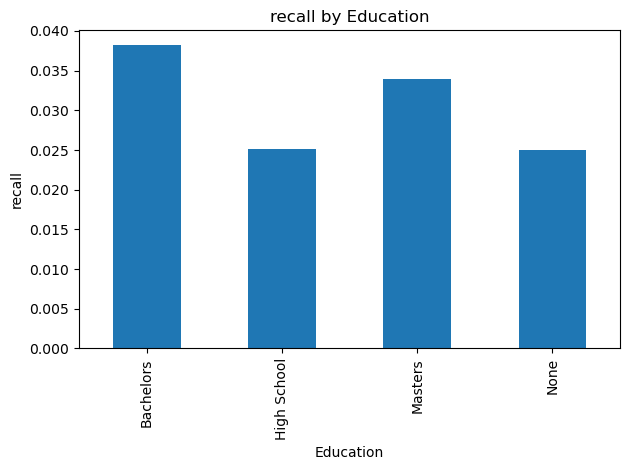

<Figure size 800x400 with 0 Axes>

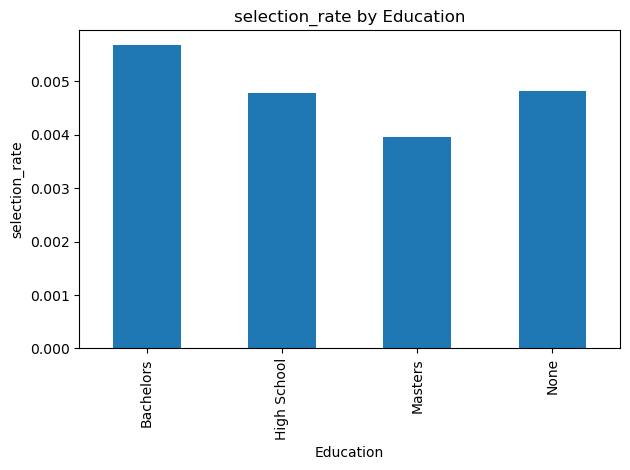

<Figure size 800x400 with 0 Axes>

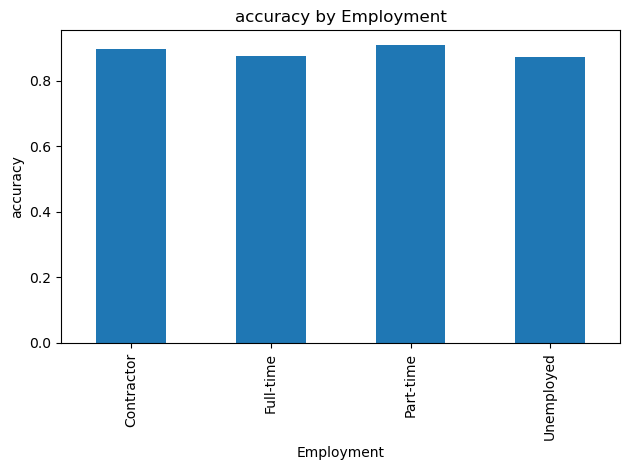

<Figure size 800x400 with 0 Axes>

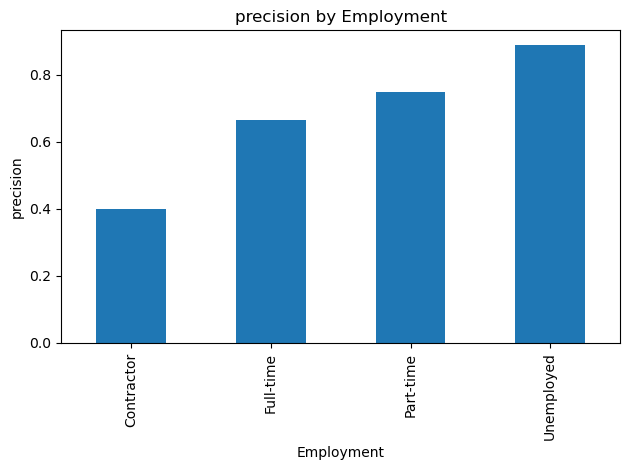

<Figure size 800x400 with 0 Axes>

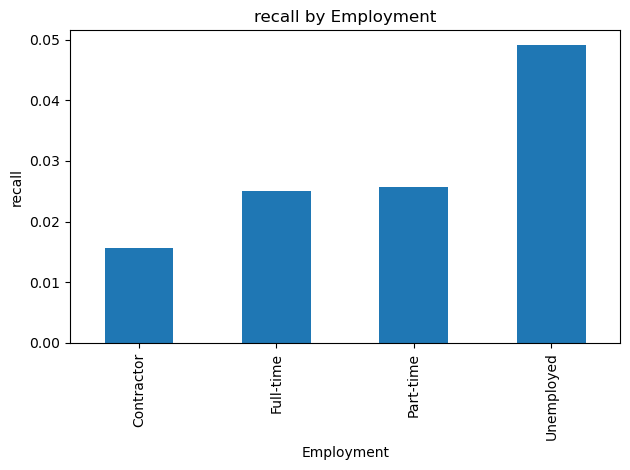

<Figure size 800x400 with 0 Axes>

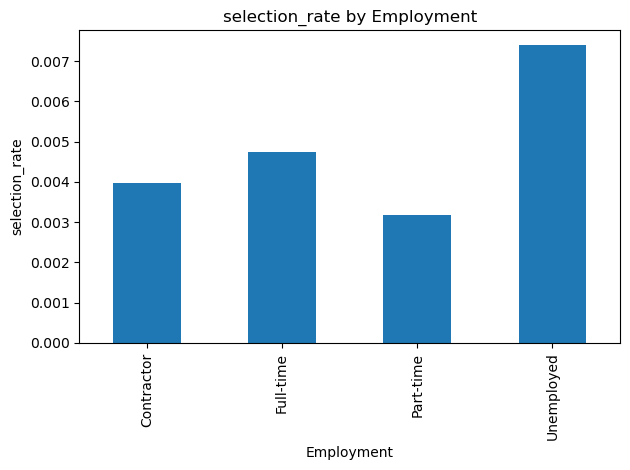

In [50]:

def plot_group_bar(df_metric: pd.DataFrame, group_name: str, metric: str):
    plt.figure(figsize=(8,4))
    df_metric.plot(x="group", y=metric, kind="bar", legend=False)
    plt.title(f"{metric} by {group_name}")
    plt.xlabel(group_name)
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

for name, dfm in results.items():
    for metric in ["accuracy", "precision", "recall", "selection_rate"]:
        plot_group_bar(dfm, name, metric)


## 6) Threshold Sweep (Selection vs Recall)

In [51]:

if 'y_proba' in globals():
    thresholds = np.linspace(0.1, 0.9, 9)
    sweep_frames = []
    for name, labels in [("Income", "income_bracket"), ("Education","education_level"), ("Employment","employment_class")]:
        if labels in df_groups:
            gseries = df_groups[labels].astype(str).reset_index(drop=True)
            for g in sorted(gseries.dropna().unique()):
                mask = (gseries == g).values
                yt = y_test.reset_index(drop=True)[mask]
                for t in thresholds:
                    yp_t = (y_proba >= t).astype(int)[mask]
                    sweep_frames.append({
                        "group_type": name,
                        "group": g,
                        "threshold": t,
                        "recall": recall_score(yt, yp_t, zero_division=0),
                        "selection_rate": float(np.mean(yp_t))
                    })
    sweep = pd.DataFrame(sweep_frames)
    display(sweep.head())
else:
    sweep = None
    print("No probability scores; skipping threshold sweep.")


,group_type,group,threshold,recall,selection_rate
0,Income,High,0.1,0.730769,0.453621
1,Income,High,0.2,0.423077,0.165171
2,Income,High,0.3,0.134615,0.040096
3,Income,High,0.4,0.044872,0.010174
4,Income,High,0.5,0.000000,0.000000


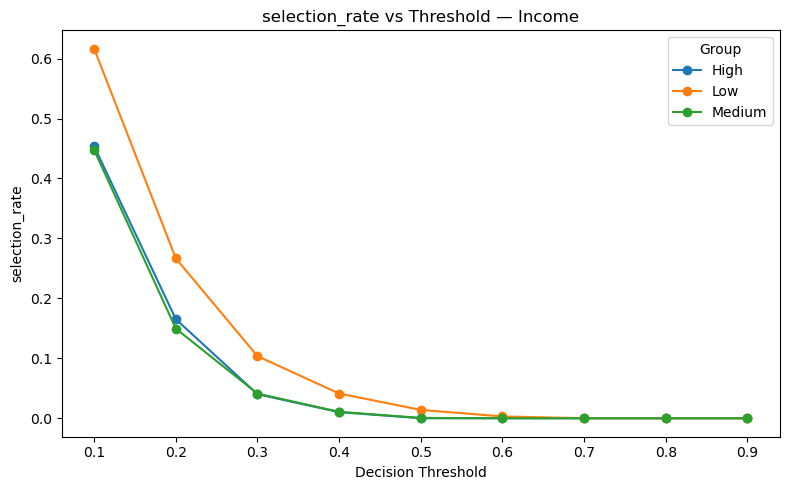

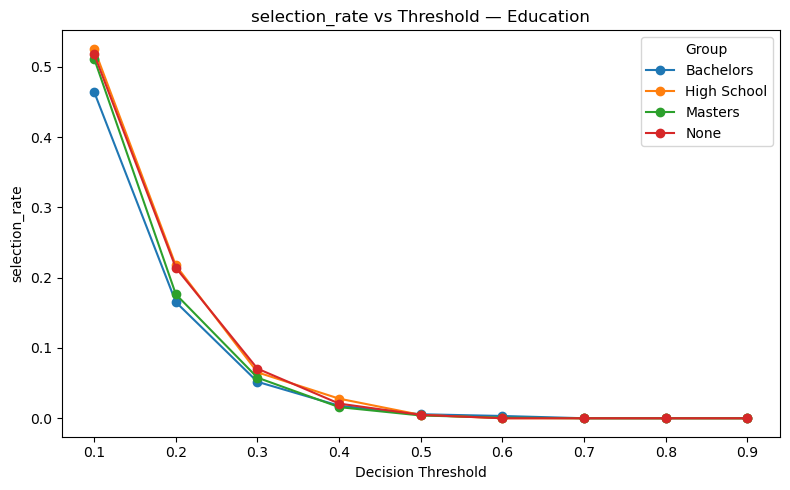

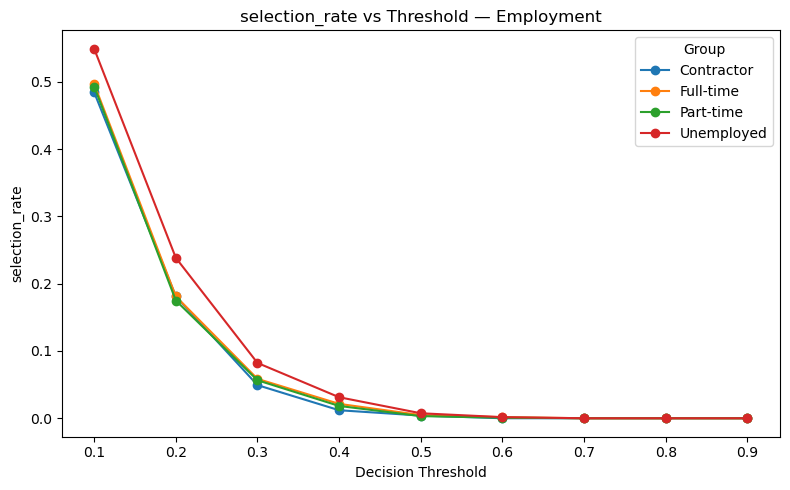

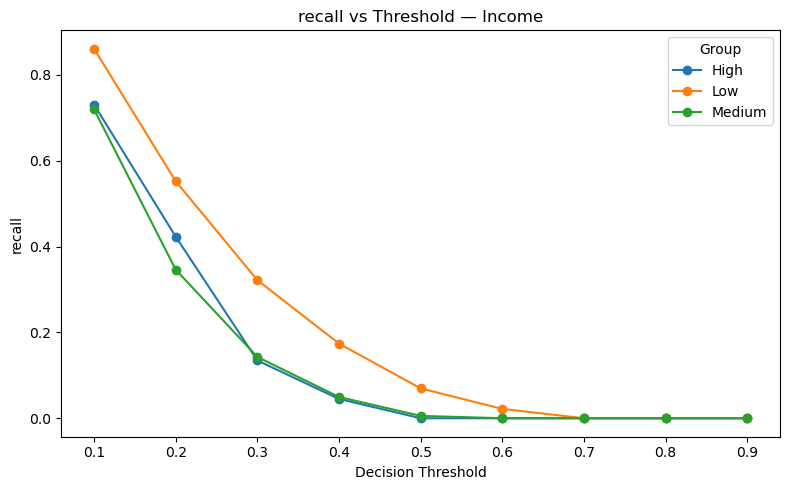

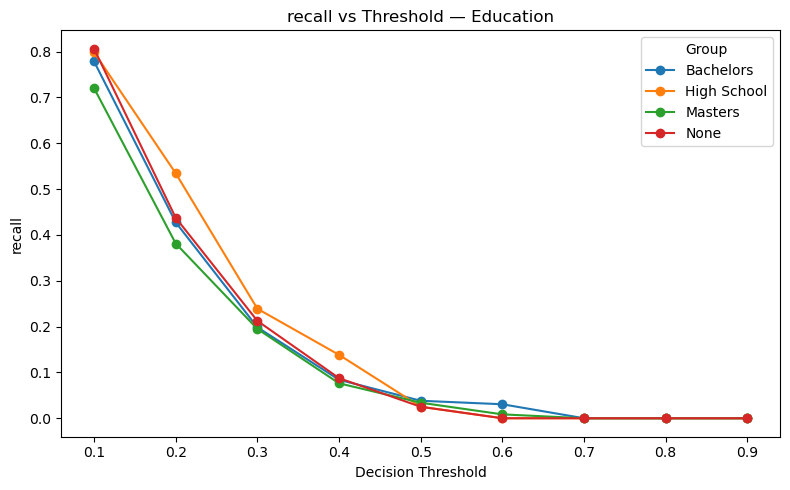

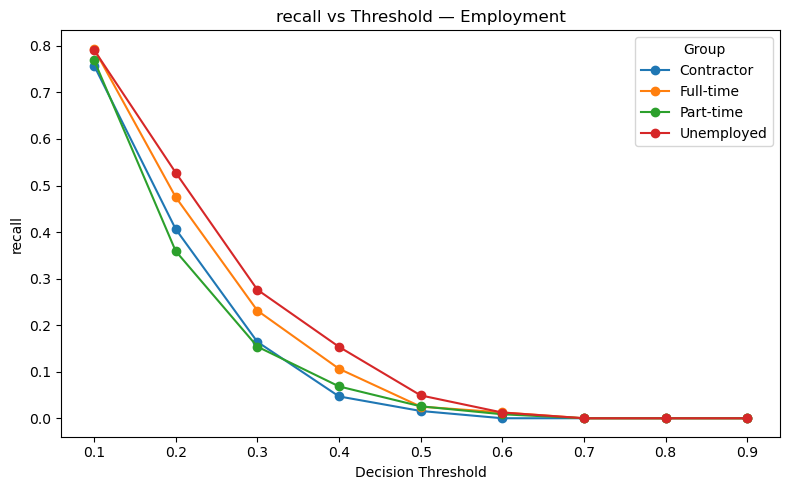

In [52]:

if isinstance(sweep, pd.DataFrame) and len(sweep):
    for metric in ["selection_rate","recall"]:
        for gtype in sweep["group_type"].unique():
            dfp = sweep[sweep["group_type"]==gtype]
            plt.figure(figsize=(8,5))
            for g in sorted(dfp["group"].unique()):
                sub = dfp[dfp["group"]==g]
                plt.plot(sub["threshold"], sub[metric], marker='o', label=g)
            plt.title(f"{metric} vs Threshold — {gtype}")
            plt.xlabel("Decision Threshold")
            plt.ylabel(metric)
            plt.legend(title="Group")
            plt.tight_layout()
            plt.show()


## 7) Save Outputs & Interpretation Notes

In [53]:
from pathlib import Path

# create ./fairness_outputs in the notebook
out_dir = Path.cwd() / "fairness_outputs"
out_dir.mkdir(parents=True, exist_ok=True)

Save everything in .fairness

In [54]:
# 1) overall metrics
pd.DataFrame([overall]).to_csv(out_dir / "overall_metrics_fairness_audit.csv", index=False)

# 2) per-group tables
for name, table in results.items():
    safe = name.lower().replace(" ", "_")
    table.to_csv(out_dir / f"fairness_{safe}.csv", index=False)

# 3) disparity summary
disparities.to_csv(out_dir / "fairness_disparities_summary.csv", index=False)

# 4) threshold sweep (if computed)
if "sweep" in globals() and isinstance(sweep, pd.DataFrame) and len(sweep):
    (out_dir / "threshold_sweep_by_group.csv").write_text("")  # ensure creatable on some FS
    sweep.to_csv(out_dir / "threshold_sweep_by_group.csv", index=False)

print("Saved files to:", out_dir.resolve())
print("\nFiles:")
for p in sorted(out_dir.glob("*")):
    print(" -", p.name)

Saved files to: /Users/taneshafuller/Documents/GitHub/AI4ALL_Credit_Risk/fairness_outputs

Files:
 - fairness_disparities_summary.csv
 - fairness_education.csv
 - fairness_employment.csv
 - fairness_income.csv
 - overall_metrics_fairness_audit.csv
 - threshold_sweep_by_group.csv



### Adding onto project??

- **Next steps:**  
  1) Tune thresholds per group or explore fairness-aware constraints.  
  2) Add tract-level context (e.g., median income, poverty rate) using a ZIP→tract crosswalk.  
  3) Use SHAP to confirm which features drive disparities.
